In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, make_scorer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
import xgboost as xgb # xgb.__version__ '2.1.3'
from catboost import CatBoostRegressor
import optuna
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [6]:
data=pd.read_excel("../Data/BUS/Bus_FE_Processed.xlsx",engine="openpyxl")
original_data=data.copy()
# data=data.drop(columns=['COST_INDEX','Unnamed: 0','區議會分區（中文名稱)','Unnamed: 0.1'])
data=data.drop(columns=['區議會分區（中文名稱)','DISTRICT_NAME_ENCODED','Unnamed: 0','COST_INDEX'])

In [7]:
data.rename(columns={
    '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2': 'median_monthly_income_by_gender_excluding_unpaid_family_workers',
    '按房屋類型劃分的有人居住的屋宇單位數目.3': 'occupied_housing_units_by_type',
    '按房屋類型劃分的家庭住戶數目.3': 'households_by_housing_type',
    '家庭住戶每月按揭供款及借貸還款與收入比率中位數': 'median_mortgage_repayment_to_income_ratio',
    '按上課地點劃分的於香港院校就讀全日制課程的人口.2': 'full_time_students_by_institution_location',
    '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2': 'households_by_number_of_rooms',
    '家庭住戶平均人數': 'average_household_size',
    '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2': 'households_with_mortgage_by_repayment_amount',
    '按房屋類型劃分的人口.3': 'population_by_housing_type',
    '按行業(9)劃分的工作人口.3': 'working_population_by_industry_9_categories',
    '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目': 'households_by_monthly_rent',
    '按行業(9)劃分的工作人口.5': 'working_population_by_industry_5_categories',
    '按工作地點劃分的工作人口.2': 'working_population_by_work_location',
    '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_unpaid_family_workers',
    '按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_foreign_domestic_workers',
    '按住戶人數劃分的家庭住戶數目': 'households_by_size',
    '按住戶結構劃分的家庭住戶數目.6': 'households_by_structure'
}, inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 42 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   PRICE                                                                    4513 non-null   float64
 1   SPECIAL_TYPE                                                             4513 non-null   int64  
 2   DISTANCE                                                                 4513 non-null   int64  
 3   JOURNEY_TIME                                                             4513 non-null   int64  
 4   MEAN_COST_INDEX                                                          4513 non-null   float64
 5   Income(Median)                                                           4513 non-null   int64  
 6   Area                                                                    

In [7]:
TARGET='PRICE'

In [8]:
def clean_non_ascii(text):
    if isinstance(text, str):
        return ''.join([char if ord(char) < 128 else '' for char in text])
    return text

data = data.map(clean_non_ascii)

In [9]:
train, test = train_test_split(data, test_size=0.3, random_state=42)

In [10]:
X = train.drop([TARGET], axis=1)
y = train[TARGET]
X_test = test.drop([TARGET], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

In [11]:
import lightgbm as lgb
import time
n_fold = 10

import matplotlib.pyplot as plt
folds = KFold(n_splits=n_fold, shuffle=True, random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

def train_model(X, X_test, y, params=None, folds=folds, model_type='lgb', plot_feature_importance=False, model=None, importance_threshold=0):

    oof = np.zeros(X.shape[0])
    prediction = np.zeros(X_test.shape[0])
    scores = []
    feature_importance = pd.DataFrame()

    # Step 1: Train and record feature importances
    for fold_n, (train_index, valid_index) in enumerate(folds.split(X)):
        print('Fold', fold_n, 'started at', time.ctime())
        if model_type == 'sklearn':
            X_train, X_valid = X[train_index], X[valid_index]
        else:
            X_train, X_valid = X.values[train_index], X.values[valid_index]
        # y_train, y_valid = y[train_index], y[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index] 

        if model_type == 'lgb':
            model = lgb.LGBMRegressor(**params, n_estimators=20000, nthread=4, n_jobs=-1)
            model.fit(X_train, y_train, 
                      eval_set=[(X_train, y_train), (X_valid, y_valid)], eval_metric='rmse')
            
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test, num_iteration=model.best_iteration_)
        
        elif model_type == 'xgb':
            train_data = xgb.DMatrix(data=X_train, label=y_train)
            valid_data = xgb.DMatrix(data=X_valid, label=y_valid)

            watchlist = [(train_data, 'train'), (valid_data, 'valid_data')]
            model = xgb.train(dtrain=train_data, num_boost_round=20000, evals=watchlist, early_stopping_rounds=200, verbose_eval=500, params=params)
            y_pred_valid = model.predict(xgb.DMatrix(X_valid), iteration_range=(0, model.best_iteration + 1))
            y_pred = model.predict(xgb.DMatrix(X_test.values),  iteration_range=(0, model.best_iteration + 1))
        
        elif model_type == 'sklearn':
            model = model
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid).reshape(-1,)
            score = mean_squared_error(y_valid, y_pred_valid)
            
            y_pred = model.predict(X_test)
        
        elif model_type == 'cat':
            model = CatBoostRegressor(iterations=20000,  eval_metric='RMSE', **params)
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=[], use_best_model=True, verbose=False)

            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        elif model_type == 'randomforest':
            model = RandomForestRegressor(**params, n_jobs=-1, random_state=42)
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        oof[valid_index] = y_pred_valid.reshape(-1,)
        mse = mean_squared_error(y_valid, y_pred_valid) ** 0.5
        print("mse----------->", mse)
        scores.append(mse)
        
        prediction += y_pred    

        if model_type == 'lgb':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)
        elif model_type =='randomforest':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    prediction /= folds.n_splits
    
    print('CV mean score: {0:.4f}, std: {1:.4f}.'.format(np.mean(scores), np.std(scores)))

    if model_type == 'lgb':
        feature_importance["importance"] /= folds.n_splits

        # Optional: Plot feature importance if specified
        if plot_feature_importance:
            cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
                by="importance", ascending=False)[:50].index
            best_features = feature_importance.loc[feature_importance.feature.isin(cols)]

            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('LGB Features (avg over folds)')
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance            
    elif model_type =='randomforest':
        feature_importance["importance"] /= folds.n_splits
        if plot_feature_importance:
            #plot the frature importance 
            cols = feature_importance.groupby("feature")["importance"].mean().sort_values(ascending=False)[:50].index
            best_features = feature_importance[feature_importance["feature"].isin(cols)]

            # 绘制条形图
            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('Random Forest Feature Importance (Avg over Folds)')
            plt.tight_layout()
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance

    else:
        return oof, prediction


In [12]:
X_train_np = X_train.values
y_train_np = y_train.values
X_valid_np = X_valid.values
y_valid_np = y_valid.values
X_train_np = np.nan_to_num(X_train_np, nan=0)
X_valid_np = np.nan_to_num(X_valid_np, nan=0)

from xgboost.callback import EarlyStopping
from lightgbm import early_stopping, log_evaluation

def objective(trial, model_type):
    if model_type == 'xgboost':
        param = {
            'objective': 'reg:squarederror',
            'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'eval_metric':'rmse',
            'early_stopping_rounds':50,
            'n_estimators': 1000
        }
        model = xgb.XGBRegressor(**param, n_jobs=-1, random_state=42)

    elif model_type == 'lightgbm':
        param = {
            'objective': 'regression',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', -1, 10),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
            'n_estimators': 1000,
            'verbosity': -1  # Suppress warnings
        }
        model = lgb.LGBMRegressor(**param, n_jobs=-1, random_state=42)

        callbacks = [early_stopping(stopping_rounds=50, verbose=False)]

    elif model_type == 'catboost':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'od_wait': trial.suggest_int('od_wait', 10, 200),
            'iterations': 1000,
            'eval_metric': 'RMSE',  # Specify evaluation metric here
            'random_state': 42,
            'silent': True  # Suppress output
        }
        model = CatBoostRegressor(**param)
    elif model_type == 'randomforest':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**param)


    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Train the model
    if model_type == 'lightgbm':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    elif model_type == 'catboost':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)]
        )
    elif model_type=='randomforest':
        model.fit(
            X_train_np, y_train_np
        )
    else:
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            #early_stopping_rounds=50,  
            verbose=False
        )

    # Predict and calculate RMSE
    y_pred = model.predict(X_valid_np)
    rmse = np.sqrt(mean_squared_error(y_valid_np, y_pred))
    return rmse

def optimize_model(model_type, n_trials=10):
    def wrapped_objective(trial):
        return objective(trial, model_type)

    study = optuna.create_study(direction='minimize')
    study.optimize(wrapped_objective, n_trials=n_trials)
    print(f"Best parameters for {model_type}:")
    print(study.best_trial.params)
    print(f"Best RMSE for {model_type}: {study.best_trial.value}")
    return study




In [13]:
lgb_study = optimize_model('lightgbm')

[I 2025-03-26 19:05:49,176] A new study created in memory with name: no-name-a82ae0e4-aab9-4203-a412-3d9beff33b09
[I 2025-03-26 19:05:50,075] Trial 0 finished with value: 1.237511364720006 and parameters: {'learning_rate': 0.09118332867055887, 'max_depth': -1, 'num_leaves': 243, 'feature_fraction': 0.677787938473033, 'bagging_fraction': 0.6112768261974417, 'lambda_l1': 1.6847771631831422e-07, 'lambda_l2': 6.010727462159226, 'min_child_samples': 2}. Best is trial 0 with value: 1.237511364720006.
[I 2025-03-26 19:05:50,258] Trial 1 finished with value: 1.2703676331394935 and parameters: {'learning_rate': 0.1987188000751042, 'max_depth': 8, 'num_leaves': 216, 'feature_fraction': 0.915856865872855, 'bagging_fraction': 0.8659627567220178, 'lambda_l1': 9.650769554741986, 'lambda_l2': 9.593432681494957e-05, 'min_child_samples': 3}. Best is trial 0 with value: 1.237511364720006.
[I 2025-03-26 19:05:50,924] Trial 2 finished with value: 1.2662891940608474 and parameters: {'learning_rate': 0.0366

Best parameters for lightgbm:
{'learning_rate': 0.1339568898224027, 'max_depth': 6, 'num_leaves': 153, 'feature_fraction': 0.8115390812441075, 'bagging_fraction': 0.6158904347601157, 'lambda_l1': 0.0429255895974629, 'lambda_l2': 1.8501515744508645e-08, 'min_child_samples': 3}
Best RMSE for lightgbm: 1.2277936704807495


Fold 0 started at Wed Mar 26 19:05:58 2025
mse-----------> 1.2752040896676242
Fold 1 started at Wed Mar 26 19:06:03 2025
mse-----------> 1.2253304324981245
Fold 2 started at Wed Mar 26 19:06:08 2025
mse-----------> 1.258673440338219
Fold 3 started at Wed Mar 26 19:06:15 2025
mse-----------> 1.2547688105775994
Fold 4 started at Wed Mar 26 19:06:21 2025
mse-----------> 1.2266073882220465
Fold 5 started at Wed Mar 26 19:06:26 2025
mse-----------> 1.3616981040915068
Fold 6 started at Wed Mar 26 19:06:31 2025
mse-----------> 1.37165548095928
Fold 7 started at Wed Mar 26 19:06:37 2025
mse-----------> 1.301934692386675
Fold 8 started at Wed Mar 26 19:06:42 2025
mse-----------> 1.042742813910768
Fold 9 started at Wed Mar 26 19:06:48 2025
mse-----------> 1.2842529335417767
CV mean score: 1.2603, std: 0.0866.


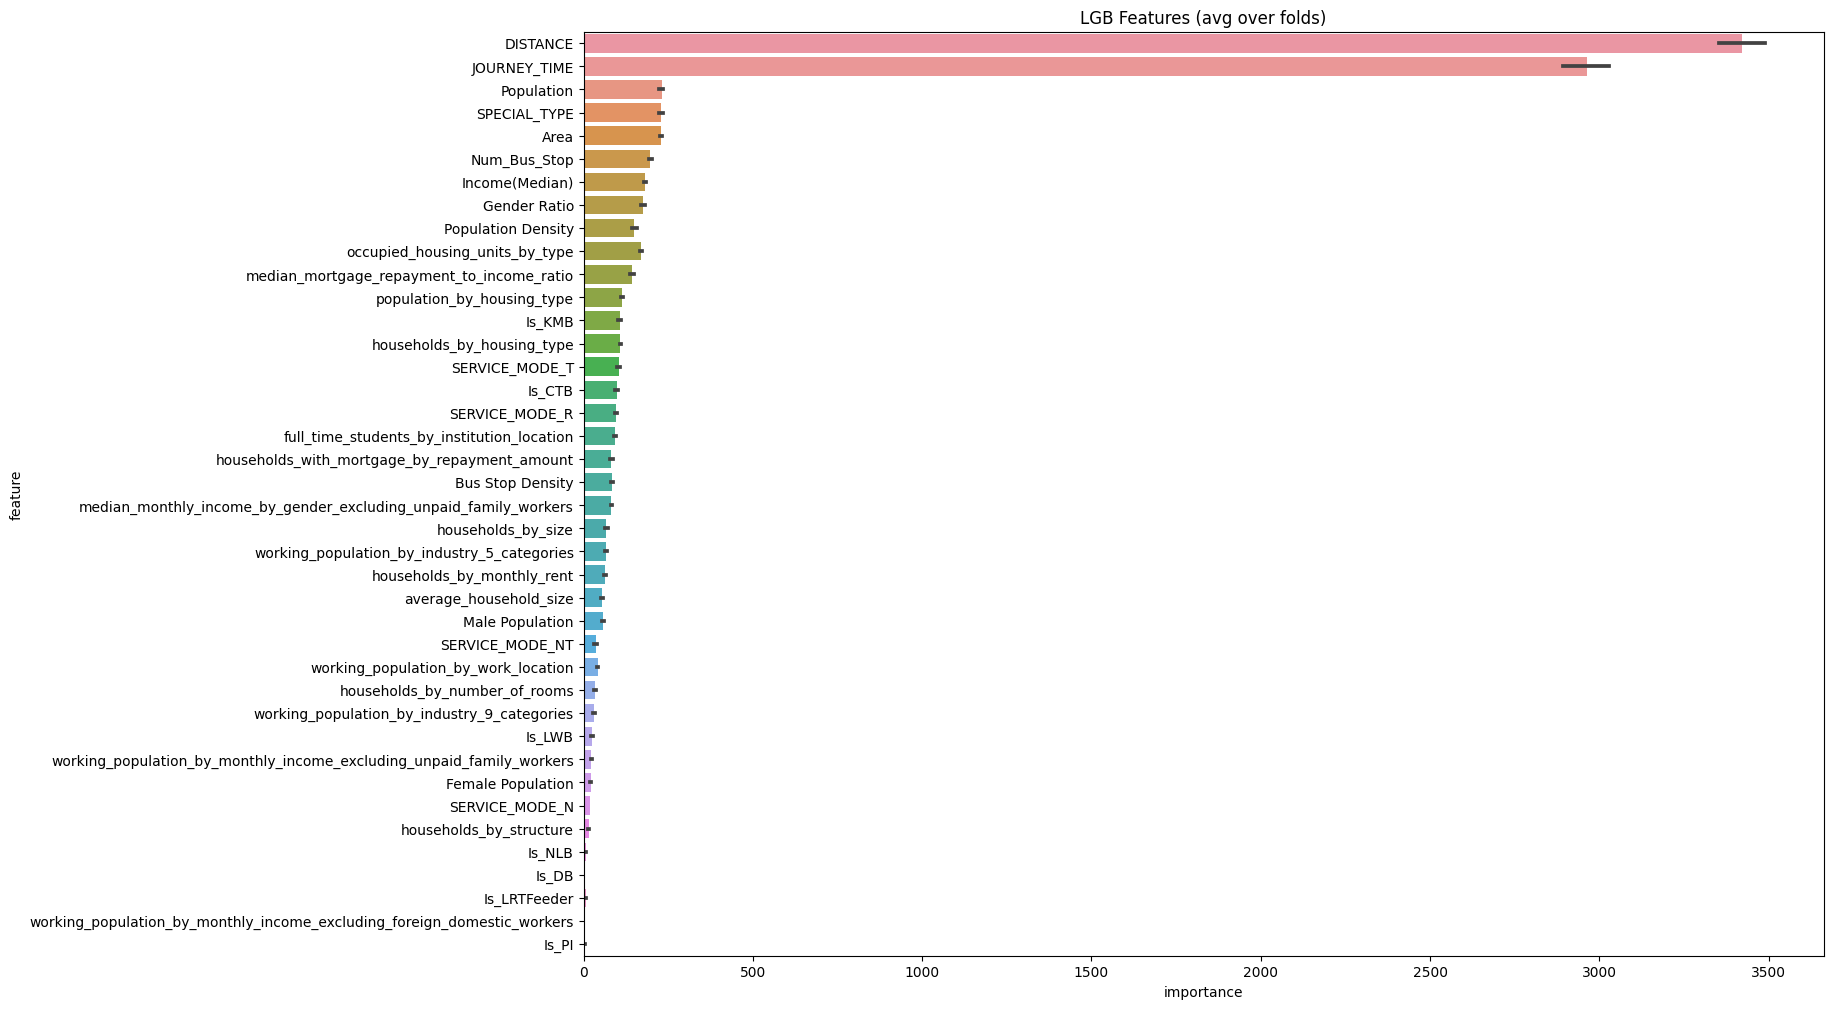

In [14]:
oof_lgb, prediction_lgb, _ = train_model(X, X_test, y, params=lgb_study.best_params, model_type='lgb', plot_feature_importance=True)


In [13]:
rf_study = optimize_model('randomforest', n_trials=50)

[I 2025-03-26 18:16:57,473] A new study created in memory with name: no-name-ff6c8f52-a5ad-4602-b7e9-d96b1a716091
[I 2025-03-26 18:16:58,059] Trial 0 finished with value: 1.419794372221996 and parameters: {'n_estimators': 400, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.419794372221996.
[I 2025-03-26 18:16:58,200] Trial 1 finished with value: 1.442186287518242 and parameters: {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 1.419794372221996.
[I 2025-03-26 18:16:58,629] Trial 2 finished with value: 1.4232613535850664 and parameters: {'n_estimators': 337, 'max_depth': 25, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 1.419794372221996.
[I 2025-03-26 18:16:59,193] Trial 3 finished with value: 1.3477070791509742 and parameters: {'n_estimators': 361, 'max_depth': 17, 'min_

Best parameters for randomforest:
{'n_estimators': 723, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None}
Best RMSE for randomforest: 1.3158162478177868


Fold 0 started at Wed Mar 26 18:18:01 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.1885357277872501
Fold 1 started at Wed Mar 26 18:18:03 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.1809028738739236
Fold 2 started at Wed Mar 26 18:18:04 2025


...

mse-----------> 1.2149202595715294
Fold 8 started at Wed Mar 26 18:18:15 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.0359443380741327
Fold 9 started at Wed Mar 26 18:18:17 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.186334045615193
CV mean score: 1.1916, std: 0.0630.


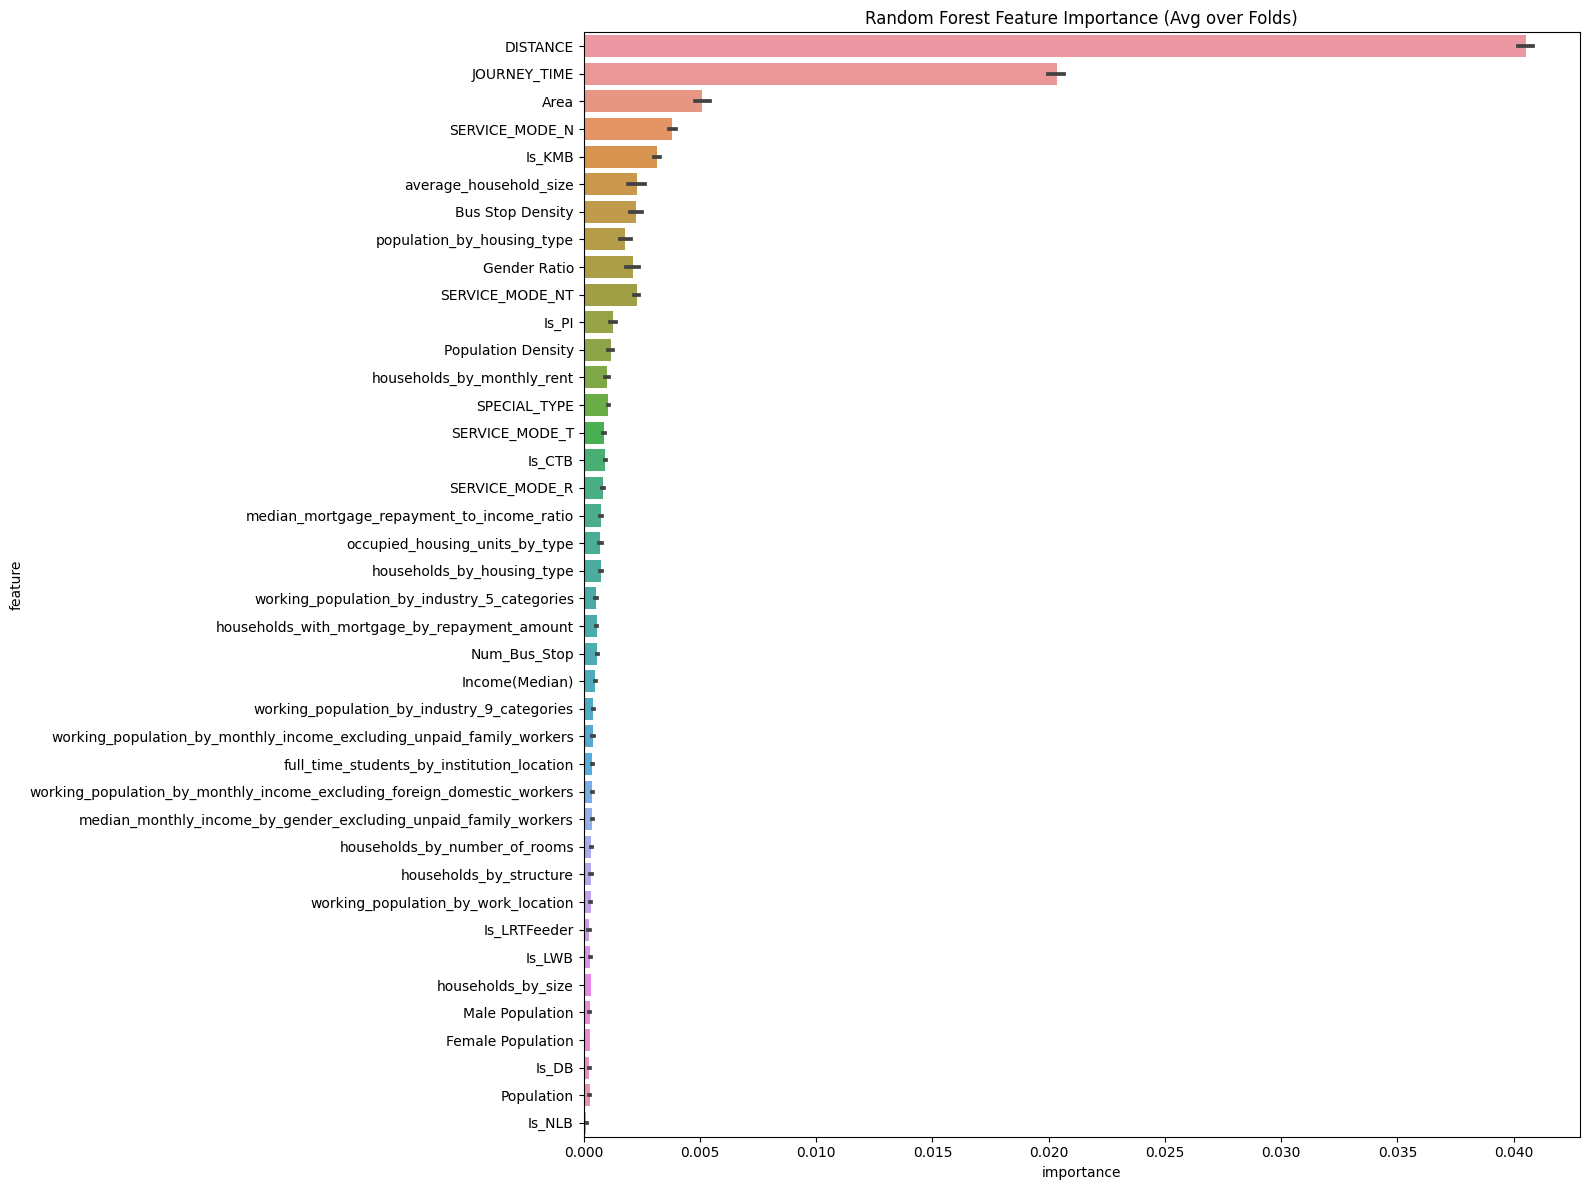

In [14]:
oof_rf, prediction_rf,feature_importance= train_model(X, X_test, y, params=rf_study.best_params, model_type='randomforest', plot_feature_importance=True)


In [15]:
catboost_study = optimize_model('catboost')

[I 2025-03-26 18:18:20,323] A new study created in memory with name: no-name-7344ad4f-f39b-4e5b-b416-18921f5eb262
[I 2025-03-26 18:18:21,397] Trial 0 finished with value: 1.306741361587902 and parameters: {'learning_rate': 0.1310565816725365, 'depth': 5, 'l2_leaf_reg': 5.064486038665227e-06, 'bagging_temperature': 6.50821904550121, 'colsample_bylevel': 0.6801525340555323, 'od_wait': 150}. Best is trial 0 with value: 1.306741361587902.
[I 2025-03-26 18:18:23,386] Trial 1 finished with value: 1.347729280700593 and parameters: {'learning_rate': 0.038656968050007706, 'depth': 3, 'l2_leaf_reg': 0.01087771921296013, 'bagging_temperature': 6.35595597241334, 'colsample_bylevel': 0.7464721456447496, 'od_wait': 175}. Best is trial 0 with value: 1.306741361587902.
[I 2025-03-26 18:18:25,037] Trial 2 finished with value: 1.3176590155877845 and parameters: {'learning_rate': 0.07913557427380417, 'depth': 4, 'l2_leaf_reg': 0.7586687265759137, 'bagging_temperature': 6.35004945440383, 'colsample_byleve

Best parameters for catboost:
{'learning_rate': 0.1747532559785809, 'depth': 6, 'l2_leaf_reg': 1.8650164275080587e-06, 'bagging_temperature': 9.61856438532379, 'colsample_bylevel': 0.9322604007334128, 'od_wait': 144}
Best RMSE for catboost: 1.2867103911462385


In [16]:

oof_cat, prediction_cat = train_model(X, X_test, y, params=catboost_study.best_params, model_type='cat')


Fold 0 started at Wed Mar 26 18:19:38 2025
mse-----------> 1.2202365082621702
Fold 1 started at Wed Mar 26 18:19:39 2025
mse-----------> 1.1651679707030114
Fold 2 started at Wed Mar 26 18:19:40 2025
mse-----------> 1.23673632017253
Fold 3 started at Wed Mar 26 18:19:41 2025
mse-----------> 1.1700051295885923
Fold 4 started at Wed Mar 26 18:19:43 2025
mse-----------> 1.1726455046904012
Fold 5 started at Wed Mar 26 18:19:44 2025
mse-----------> 1.2838625318407093
Fold 6 started at Wed Mar 26 18:19:45 2025
mse-----------> 1.25736201343387
Fold 7 started at Wed Mar 26 18:19:46 2025
mse-----------> 1.2418387648222466
Fold 8 started at Wed Mar 26 18:19:48 2025
mse-----------> 1.0262734150325283
Fold 9 started at Wed Mar 26 18:19:50 2025
mse-----------> 1.240291323174818
CV mean score: 1.2014, std: 0.0696.


In [191]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lgb_rmse = np.sqrt(mean_squared_error(test[TARGET], prediction_lgb))
rf_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_rf))
cat_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_cat))
lgb_r2=r2_score(test[TARGET], prediction_lgb)
rf_r2=r2_score(test[TARGET], prediction_rf)
cat_r2=r2_score(test[TARGET], prediction_cat)
print(prediction_lgb)


print("LGB_RMSE:", lgb_rmse)
print("RF_RMSE:", rf_rmse)
print("CAT_RMSE:", cat_rmse)
print('LGB_R2: ', lgb_r2)
print('LGB_R2: ', rf_r2)
print('LGB_R2: ', cat_r2)


[7.32878959 5.12729832 6.77546919 ... 4.45308672 5.42591692 3.28984831]
LGB_RMSE: 1.1845232557824674
RF_RMSE: 1.1571195655770088
CAT_RMSE: 1.1563466563152325
LGB_R2:  0.4928535585925232
LGB_R2:  0.516047571779755
LGB_R2:  0.5166938773121283


In [16]:
import pandas as pd
import numpy as np
outlier=test.copy()

outlier['residuals'] = test[TARGET] - prediction_lgb

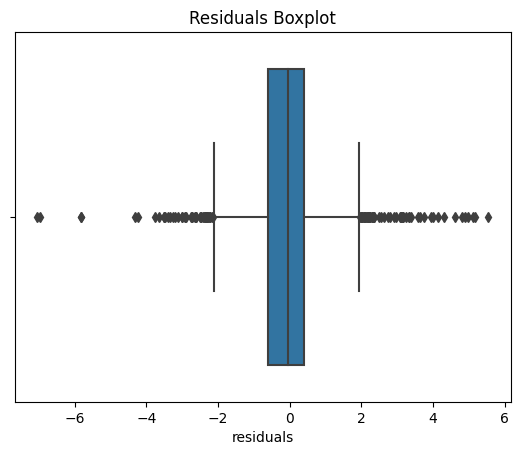

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制箱线图
sns.boxplot(x=outlier['residuals'])
plt.title('Residuals Boxplot')
plt.show()

# 计算异常阈值
Q1 = outlier['residuals'].quantile(0.25)
Q3 = outlier['residuals'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 标记异常点
boxplot_outliers = outlier[ (outlier['residuals'] > upper_bound)]

In [24]:
mean = outlier['residuals'].mean()
std = outlier['residuals'].std()
lower_sigma = mean - 2 * std
upper_sigma = mean + 2 * std

# 标记异常点
sigma_outliers = outlier[ (outlier['residuals'] > upper_sigma)]

In [25]:
boxplot_outliers_regions = original_data.loc[boxplot_outliers.index, '區議會分區（中文名稱)']
sigma_outliers_regions = original_data.loc[sigma_outliers.index, '區議會分區（中文名稱)']

In [27]:
# 检查预处理后的数据是否保留了原始索引
print("预处理数据索引是否与原始数据一致:", data.index.equals(original_data.index))

# 检查异常点的索引是否在原始数据中存在
print("箱线图异常点索引是否在原始数据中:", boxplot_outliers.index.isin(original_data.index).all())
print("标准差异常点索引是否在原始数据中:", sigma_outliers.index.isin(original_data.index).all())

预处理数据索引是否与原始数据一致: True
箱线图异常点索引是否在原始数据中: True
标准差异常点索引是否在原始数据中: True


In [28]:
# 随机选择3个箱线图异常点
sample_outliers = boxplot_outliers.sample(3, random_state=42)

# 显示这些点的残差和对应区域
for idx, row in sample_outliers.iterrows():
    original_region = original_data.loc[idx, '區議會分區（中文名稱)']
    print(f"索引: {idx}, 残差: {row['residuals']:.2f}, 原始区域: {original_region}")

索引: 245, 残差: 2.17, 原始区域: 深水埗
索引: 4399, 残差: 3.34, 原始区域: 大埔
索引: 3928, 残差: 3.65, 原始区域: 屯門


In [26]:
# 统计箱线图法的异常区域分布
boxplot_region_counts = boxplot_outliers_regions.value_counts(normalize=True) * 100
print("箱线图法异常区域占比:\n", boxplot_region_counts)

# 统计标准差法的异常区域分布
sigma_region_counts = sigma_outliers_regions.value_counts(normalize=True) * 100
print("标准差法异常区域占比:\n", sigma_region_counts)

箱线图法异常区域占比:
 區議會分區（中文名稱)
葵青     18.181818
沙田     10.606061
灣仔     10.606061
南區      9.090909
油尖旺     9.090909
屯門      6.060606
中西區     6.060606
深水埗     4.545455
觀塘      4.545455
東區      4.545455
離島      3.030303
北區      3.030303
大埔      3.030303
西貢      3.030303
荃灣      3.030303
九龍城     1.515152
Name: proportion, dtype: float64
标准差法异常区域占比:
 區議會分區（中文名稱)
葵青     25.641026
油尖旺    12.820513
屯門     10.256410
沙田     10.256410
南區     10.256410
灣仔      7.692308
中西區     7.692308
東區      5.128205
離島      2.564103
荃灣      2.564103
西貢      2.564103
大埔      2.564103
Name: proportion, dtype: float64


In [30]:
import pandas as pd

# 假设已有以下变量：
# boxplot_region_counts, sigma_region_counts, original_data

# 获取所有区域名称
all_regions = original_data['區議會分區（中文名稱)'].unique()

# 箱线图法排名
boxplot_ranks = (
    boxplot_region_counts
    .reindex(all_regions, fill_value=0)
    .rank(method='min')
    .astype(int)
)

# 标准差法排名
sigma_ranks = (
    sigma_region_counts
    .reindex(all_regions, fill_value=0)
    .rank(method='min')
    .astype(int)
)

# 计算平均排名
average_ranks = (boxplot_ranks + sigma_ranks) / 2

# 整合结果
result = pd.DataFrame({
    '区域': all_regions,
    '箱线图法排名': boxplot_ranks,
    '标准差法排名': sigma_ranks,
    '平均排名': average_ranks.round(2)
}).sort_values('平均排名')
result

,区域,箱线图法排名,标准差法排名,平均排名
區議會分區（中文名稱),,,,
黃大仙,黃大仙,1,1,1.0
元朗,元朗,1,1,1.0
九龍城,九龍城,3,1,2.0
北區,北區,4,1,2.5
深水埗,深水埗,9,1,5.0
觀塘,觀塘,9,1,5.0
離島,離島,4,7,5.5
大埔,大埔,4,7,5.5
西貢,西貢,4,7,5.5


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


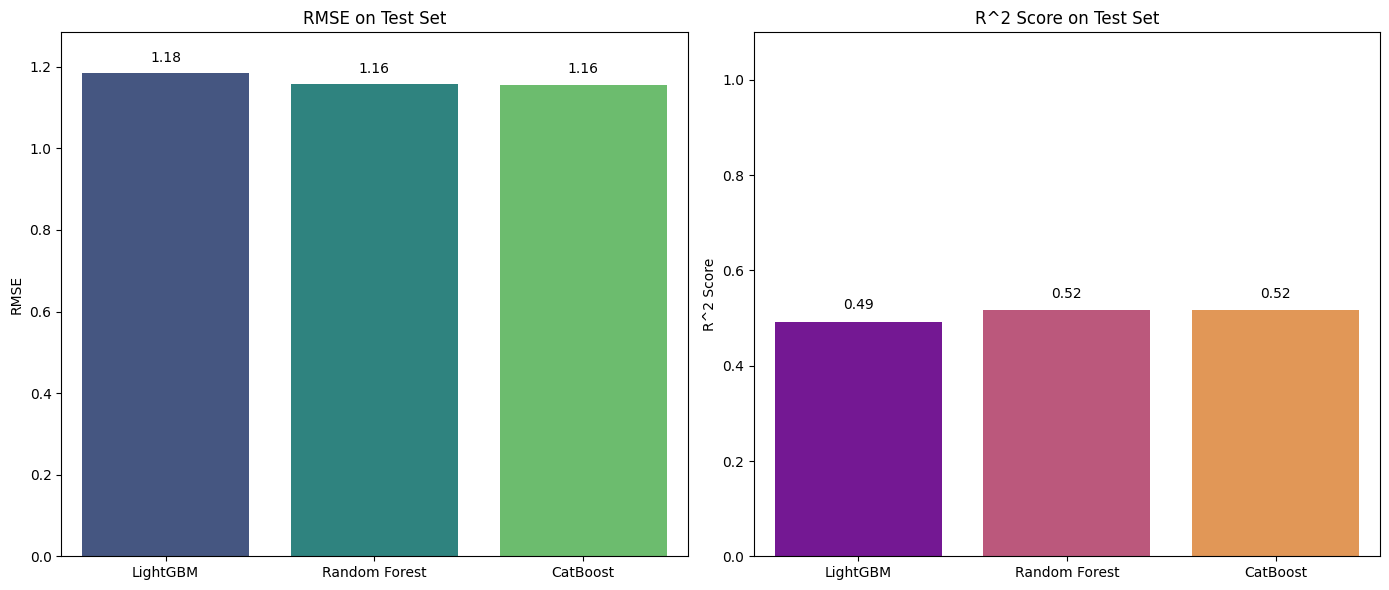

In [192]:
# 数据整理

models = ['LightGBM', 'Random Forest', 'CatBoost']
rmse_scores = [lgb_rmse, rf_rmse, cat_rmse]
r2_scores = [lgb_r2, rf_r2, cat_r2]

# 创建画布
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 绘制 RMSE 柱状图
sns.barplot(x=models, y=rmse_scores, ax=axes[0], palette='viridis')
axes[0].set_title('RMSE on Test Set')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_scores) + 0.1)  # 设置 y 轴范围

# 在柱子上标注数值
for i, score in enumerate(rmse_scores):
    axes[0].text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# 绘制 R^2 柱状图
sns.barplot(x=models, y=r2_scores, ax=axes[1], palette='plasma')
axes[1].set_title('R^2 Score on Test Set')
axes[1].set_ylabel('R^2 Score')
axes[1].set_ylim(0, 1.1)  # 设置 y 轴范围

# 在柱子上标注数值
for i, score in enumerate(r2_scores):
    axes[1].text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# 调整布局
plt.tight_layout()
plt.show()

In [32]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_graphviz
# 训练决策树模型
dt_regressor = DecisionTreeRegressor(
    max_depth=5,  # 控制树的最大深度（避免过深导致可视化不清晰）
    random_state=42
)
dt_regressor.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

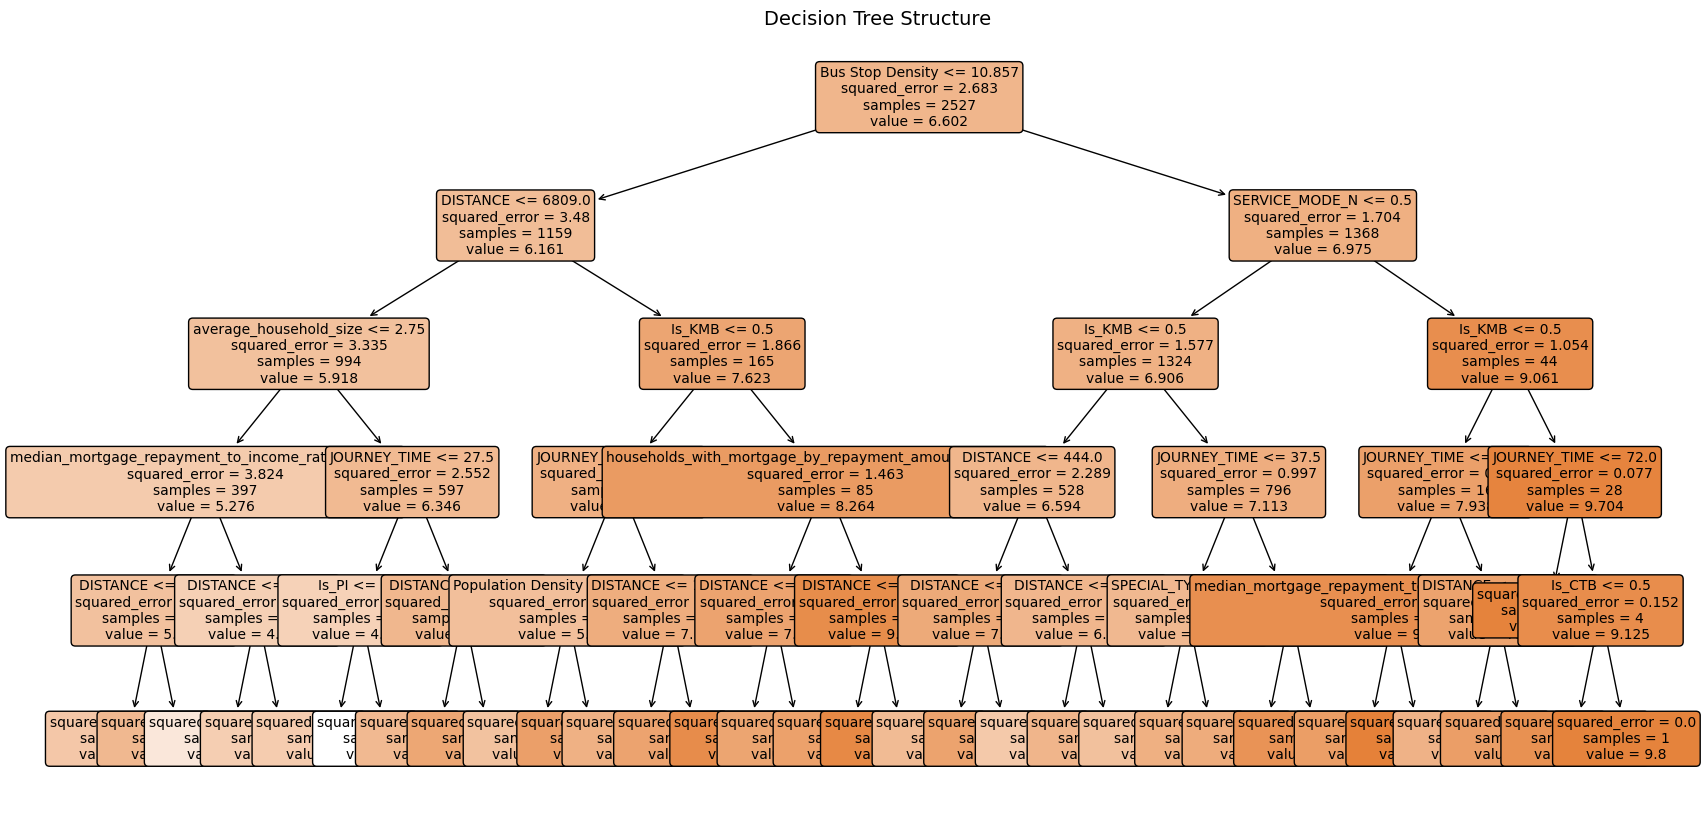

In [33]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_regressor,
    feature_names=X.columns,  # 显示特征名称
    filled=True,              # 填充颜色表示目标值
    rounded=True,             # 圆角节点
    fontsize=10
)
plt.title("Decision Tree Structure", fontsize=14)
plt.show()